Using device: mps
TRAINING ON KINECT DATA
Kinect model parameters: 49,805
Epoch   0: Train Loss=0.031811, Val Loss=0.004413, Train MAE=0.1226, Val MAE=0.0487, LR=0.001000
Epoch  50: Train Loss=0.001987, Val Loss=0.000977, Train MAE=0.0333, Val MAE=0.0236, LR=0.001000
  → Learning rate reduced to 0.000500
Epoch 100: Train Loss=0.001721, Val Loss=0.000879, Train MAE=0.0312, Val MAE=0.0224, LR=0.000500
  → Learning rate reduced to 0.000250
Epoch 150: Train Loss=0.001572, Val Loss=0.000597, Train MAE=0.0297, Val MAE=0.0188, LR=0.000250
  → Learning rate reduced to 0.000125
Epoch 200: Train Loss=0.001444, Val Loss=0.000543, Train MAE=0.0286, Val MAE=0.0178, LR=0.000125
  → Learning rate reduced to 0.000063
Epoch 250: Train Loss=0.001357, Val Loss=0.000478, Train MAE=0.0278, Val MAE=0.0169, LR=0.000063
  → Learning rate reduced to 0.000031

TRAINING ON MEDIAPIPE DATA
MediaPipe model parameters: 49,805
Epoch   0: Train Loss=0.031250, Val Loss=0.004603, Train MAE=0.1217, Val MAE=0.0499, LR=0.0

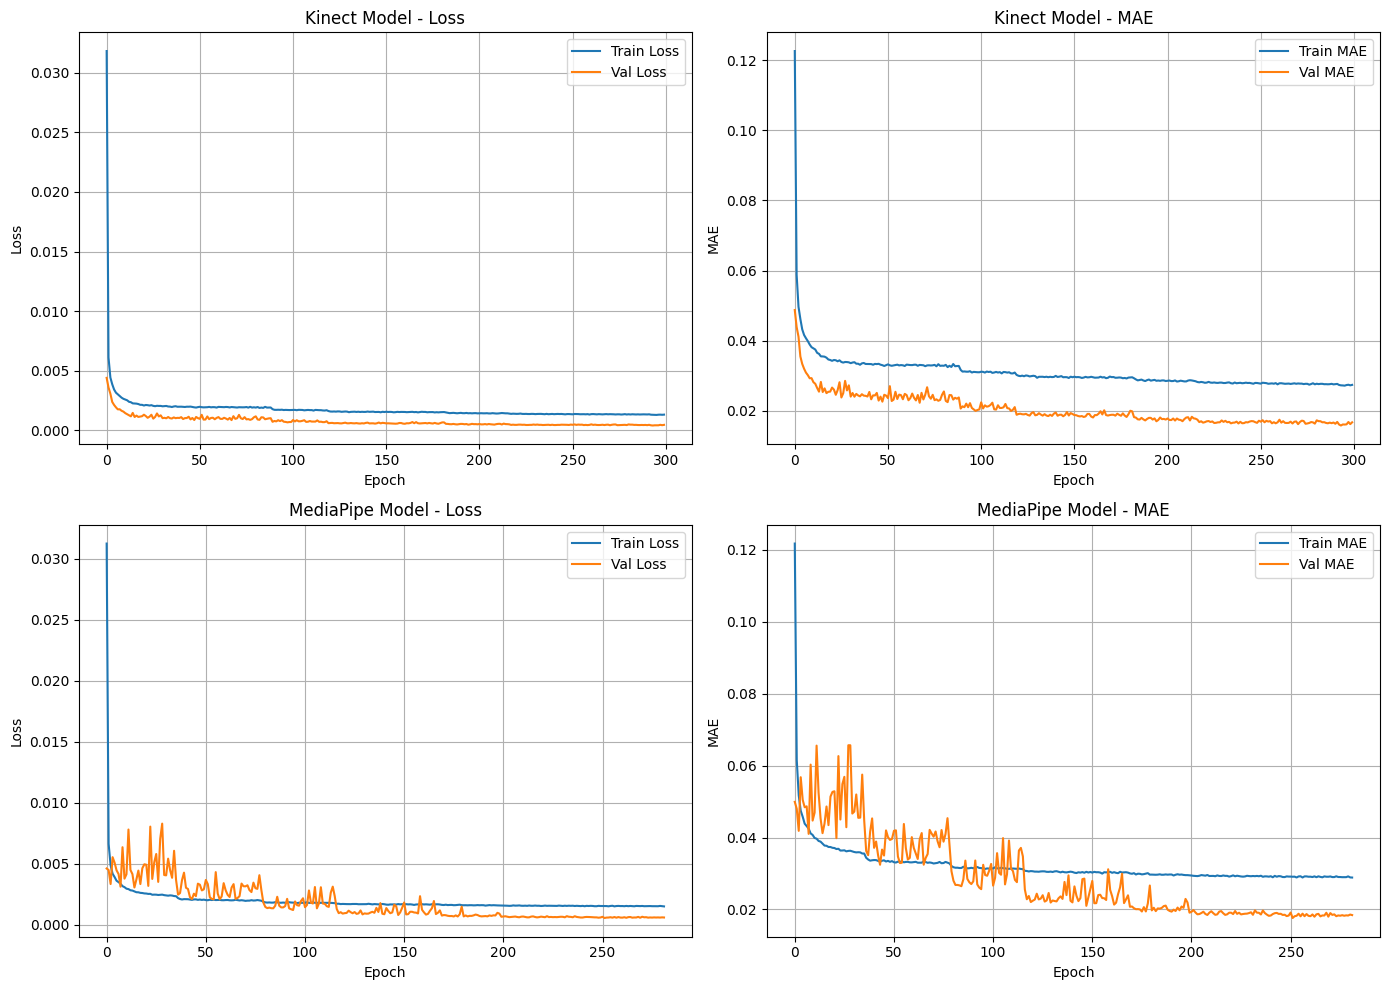


FINAL SUMMARY

Configuration used (SAME for both):
  Hidden layers: [256, 128, 64]
  Dropout: 0.3
  Learning rate: 0.001
  Batch size: 64
  Weight decay: 1e-05

Results:
  Kinect Model Test MAE:    3.24 cm (R²=0.8488)
  MediaPipe Model Test MAE: 3.07 cm (R²=0.8673)


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import sys
import numpy as np
import os
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
sys.path.append("../../MainProject/Assignment9")
from assignment9_functions import *

random_seed = 42

def load_aligned_pair(mp_file, kinect_file, mp_dir, kinect_dir):
    df_mp = pd.read_csv(os.path.join(mp_dir, mp_file))
    df_kinect = pd.read_csv(os.path.join(kinect_dir, kinect_file))

    df_kinect.columns = df_kinect.columns.str.strip()

    # Align frames
    frames = df_kinect["FrameNo"].values
    df_mp = df_mp[df_mp["FrameNo"].isin(frames)]

    df_mp = df_mp.reset_index(drop=True)
    df_kinect = df_kinect.reset_index(drop=True)

    return df_mp, df_kinect

# Set device
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# Load kinect data
kinect_data = "../../MainProject/Assignment9/data/kinect_good_preprocessed"
train_files_kinect, test_files_kinect = split_csvfiles(kinect_data, random_seed, 0.9, 0)


# Load Mediapipe data, ensure split is consistent with how kinect was splitted
mp_data = "../../MainProject/Assignment10/data/csv_of_all_videos"
train_files_mp = [f.replace("kinect", "mediapipe") for f in train_files_kinect]
test_files_mp = [f.replace("kinect", "mediapipe") for f in test_files_kinect]


# Align mediapipe and kinect training data
train_mp_list = []
train_kinect_list = []
for mp_file, kinect_file in zip(train_files_mp, train_files_kinect):
    df_mp, df_kinect = load_aligned_pair(mp_file, kinect_file, mp_data, kinect_data)

    train_mp_list.append(df_mp)
    train_kinect_list.append(df_kinect)

train_data_mp = pd.concat(train_mp_list, ignore_index=True)
train_data_kinect = pd.concat(train_kinect_list, ignore_index=True)

# Align mediapipe and kinect testing data
test_mp_list = []
test_kinect_list = []
for mp_file, kinect_file in zip(test_files_mp, test_files_kinect):
    df_mp, df_kinect = load_aligned_pair(mp_file, kinect_file, mp_data, kinect_data)

    test_mp_list.append(df_mp)
    test_kinect_list.append(df_kinect)

test_data_mp = pd.concat(test_mp_list, ignore_index=True)
test_data_kinect = pd.concat(test_kinect_list, ignore_index=True)

# Split based on input (x,y) and target (z)
x_train_kinect, y_train_kinect = input_target_split(train_data_kinect)
x_test_kinect, y_test_kinect = input_target_split(test_data_kinect)

x_train_mp, y_train_mp = input_target_split(train_data_mp)
x_test_mp, y_test_mp = input_target_split(test_data_mp)

X_train_kinect = torch.tensor(x_train_kinect.values, dtype=torch.float32)
Y_train_kinect = torch.tensor(y_train_kinect.values, dtype=torch.float32)
X_test_kinect = torch.tensor(x_test_kinect.values, dtype=torch.float32)
Y_test_kinect = torch.tensor(y_test_kinect.values, dtype=torch.float32)

# Convert MediaPipe data to tensors
X_train_mp = torch.tensor(x_train_mp.values, dtype=torch.float32)
Y_train_mp = torch.tensor(y_train_mp.values, dtype=torch.float32)
X_test_mp = torch.tensor(x_test_mp.values, dtype=torch.float32)
Y_test_mp = torch.tensor(y_test_mp.values, dtype=torch.float32)
# ============================================
# DENSE NETWORK ARCHITECTURE
# ============================================

class DenseZPredictor(nn.Module):
    """
    Dense neural network for predicting Z-depth from X,Y coordinates
    """
    def __init__(self, hidden_layers=[256, 128, 64], dropout=0.3, input_size=26, output_size=13):
        super(DenseZPredictor, self).__init__()
        
        layers = []
        prev_size = input_size
        
        # Build hidden layers
        for hidden_size in hidden_layers:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_size = hidden_size
        
        # Output layer
        layers.append(nn.Linear(prev_size, output_size))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        # x shape: (batch, 26) or (batch, seq_length, 26)
        # For sequences, flatten or process each frame
        if x.dim() == 3:
            batch, seq, features = x.shape
            x = x.view(batch * seq, features)
            out = self.network(x)
            return out.view(batch, seq, -1)
        else:
            return self.network(x)


# ============================================
# TRAINING FUNCTION
# ============================================

def train_dense_model(model, X_train, Y_train, X_val, Y_val, config, verbose=True):
    """
    Train dense model with the given configuration
    """
    # Create data loaders
    train_dataset = TensorDataset(X_train, Y_train)
    val_dataset = TensorDataset(X_val, Y_val)
    
    train_loader = DataLoader(train_dataset, batch_size=config["batch_size"], shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=config["batch_size"], shuffle=False)
    
    # Loss function and optimizer
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=config["learning_rate"], 
                          weight_decay=config.get("weight_decay", 0))
    
    # Learning rate scheduler (removed verbose parameter)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
                                                      factor=0.5, patience=20)
    
    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0
    previous_lr = config["learning_rate"]
    
    history = {'train_loss': [], 'val_loss': [], 'train_mae': [], 'val_mae': []}
    
    for epoch in range(config["epochs"]):
        # Training
        model.train()
        train_losses = []
        train_maes = []
        
        for batch_X, batch_Y in train_loader:
            batch_X, batch_Y = batch_X.to(device), batch_Y.to(device)
            
            optimizer.zero_grad()
            predictions = model(batch_X)
            loss = criterion(predictions, batch_Y)
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            train_losses.append(loss.item())
            train_maes.append(torch.mean(torch.abs(predictions - batch_Y)).item())
        
        # Validation
        model.eval()
        val_losses = []
        val_maes = []
        
        with torch.no_grad():
            for batch_X, batch_Y in val_loader:
                batch_X, batch_Y = batch_X.to(device), batch_Y.to(device)
                predictions = model(batch_X)
                loss = criterion(predictions, batch_Y)
                
                val_losses.append(loss.item())
                val_maes.append(torch.mean(torch.abs(predictions - batch_Y)).item())
        
        avg_train_loss = np.mean(train_losses)
        avg_train_mae = np.mean(train_maes)
        avg_val_loss = np.mean(val_losses)
        avg_val_mae = np.mean(val_maes)
        
        # Store history
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_mae'].append(avg_train_mae)
        history['val_mae'].append(avg_val_mae)
        
        # Learning rate scheduling
        scheduler.step(avg_val_loss)
        
        # Check if learning rate changed
        current_lr = optimizer.param_groups[0]['lr']
        if current_lr != previous_lr:
            if verbose:
                print(f"  → Learning rate reduced to {current_lr:.6f}")
            previous_lr = current_lr
        
        # Save best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
        
        if verbose and epoch % 50 == 0:
            print(f"Epoch {epoch:3d}: Train Loss={avg_train_loss:.6f}, Val Loss={avg_val_loss:.6f}, "
                  f"Train MAE={avg_train_mae:.4f}, Val MAE={avg_val_mae:.4f}, LR={current_lr:.6f}")
        
        # Early stopping
        if config.get("patience") and patience_counter >= config["patience"]:
            if verbose:
                print(f"Early stopping at epoch {epoch}")
            break
    
    # Load best model
    model.load_state_dict(best_state)
    
    return model, history


# ============================================
# EVALUATION FUNCTION
# ============================================

def evaluate_dense_model(model, X_test, Y_test):
    """
    Evaluate dense model on test data
    """
    model.eval()
    
    with torch.no_grad():
        X_test = X_test.to(device)
        Y_test = Y_test.to(device)
        
        predictions = model(X_test)
        
        # Move to CPU for metrics
        predictions = predictions.cpu().numpy()
        Y_test = Y_test.cpu().numpy()
        
        # Calculate metrics
        mse = mean_squared_error(Y_test.flatten(), predictions.flatten())
        mae = mean_absolute_error(Y_test.flatten(), predictions.flatten())
        r2 = r2_score(Y_test.flatten(), predictions.flatten())
        bias = np.mean(predictions.flatten() - Y_test.flatten())
        
    return {
        'mse': mse,
        'mae': mae,
        'r2': r2,
        'bias': bias,
        'predictions': predictions
    }


# ============================================
# CONFIGURATION (SAME FOR BOTH DATASETS)
# ============================================

config = {
    "hidden_layers": [256, 128, 64],
    "dropout": 0.3,
    "learning_rate": 0.001,
    "batch_size": 64,
    "epochs": 300,
    "weight_decay": 1e-5,
    "patience": 30,
}


# ============================================
# TRAIN ON KINECT DATA
# ============================================

print("="*60)
print("TRAINING ON KINECT DATA")
print("="*60)

# Prepare Kinect data (already have X_train_kinect, Y_train_kinect, etc.)
# Split into train/val for Kinect
from sklearn.model_selection import train_test_split

kinect_train_x, kinect_val_x, kinect_train_y, kinect_val_y = train_test_split(
    X_train_kinect.cpu().numpy(), 
    Y_train_kinect.cpu().numpy(), 
    test_size=0.1, 
    random_state=42
)

# Convert back to tensors
kinect_train_x = torch.tensor(kinect_train_x, dtype=torch.float32).to(device)
kinect_val_x = torch.tensor(kinect_val_x, dtype=torch.float32).to(device)
kinect_train_y = torch.tensor(kinect_train_y, dtype=torch.float32).to(device)
kinect_val_y = torch.tensor(kinect_val_y, dtype=torch.float32).to(device)

# Create and train Kinect model
kinect_model = DenseZPredictor(
    hidden_layers=config["hidden_layers"],
    dropout=config["dropout"]
).to(device)

print(f"Kinect model parameters: {sum(p.numel() for p in kinect_model.parameters()):,}")

kinect_model, kinect_history = train_dense_model(
    kinect_model, 
    kinect_train_x, kinect_train_y,
    kinect_val_x, kinect_val_y,
    config,
    verbose=True
)

# Evaluate on Kinect test data
kinect_results = evaluate_dense_model(kinect_model, X_test_kinect, Y_test_kinect)


# ============================================
# TRAIN ON MEDIAPIPE DATA
# ============================================

print("\n" + "="*60)
print("TRAINING ON MEDIAPIPE DATA")
print("="*60)

# Prepare MediaPipe data
mp_train_x, mp_val_x, mp_train_y, mp_val_y = train_test_split(
    X_train_mp.cpu().numpy(), 
    Y_train_kinect.cpu().numpy(),  # Using Kinect Z as target
    test_size=0.1, 
    random_state=42
)

# Convert back to tensors
mp_train_x = torch.tensor(mp_train_x, dtype=torch.float32).to(device)
mp_val_x = torch.tensor(mp_val_x, dtype=torch.float32).to(device)
mp_train_y = torch.tensor(mp_train_y, dtype=torch.float32).to(device)
mp_val_y = torch.tensor(mp_val_y, dtype=torch.float32).to(device)

# Create and train MediaPipe model (SAME ARCHITECTURE)
mp_model = DenseZPredictor(
    hidden_layers=config["hidden_layers"],
    dropout=config["dropout"]
).to(device)

print(f"MediaPipe model parameters: {sum(p.numel() for p in mp_model.parameters()):,}")

mp_model, mp_history = train_dense_model(
    mp_model,
    mp_train_x, mp_train_y,
    mp_val_x, mp_val_y,
    config,
    verbose=True
)

# Evaluate on MediaPipe test data
mp_results = evaluate_dense_model(mp_model, X_test_mp, Y_test_kinect)


# ============================================
# COMPARE RESULTS
# ============================================

print("\n" + "="*60)
print("COMPARISON: Kinect vs MediaPipe Training")
print("="*60)

comparison_df = pd.DataFrame({
    "Metric": ["MSE", "MAE (m)", "MAE (cm)", "R²", "Bias"],
    "Kinect Model": [
        f"{kinect_results['mse']:.6f}",
        f"{kinect_results['mae']:.4f}",
        f"{kinect_results['mae']*100:.2f}",
        f"{kinect_results['r2']:.4f}",
        f"{kinect_results['bias']:.6f}"
    ],
    "MediaPipe Model": [
        f"{mp_results['mse']:.6f}",
        f"{mp_results['mae']:.4f}",
        f"{mp_results['mae']*100:.2f}",
        f"{mp_results['r2']:.4f}",
        f"{mp_results['bias']:.6f}"
    ]
})

print(comparison_df.to_string(index=False))


# ============================================
# PLOT TRAINING CURVES
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Kinect training curves
axes[0, 0].plot(kinect_history['train_loss'], label='Train Loss')
axes[0, 0].plot(kinect_history['val_loss'], label='Val Loss')
axes[0, 0].set_title('Kinect Model - Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(kinect_history['train_mae'], label='Train MAE')
axes[0, 1].plot(kinect_history['val_mae'], label='Val MAE')
axes[0, 1].set_title('Kinect Model - MAE')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('MAE')
axes[0, 1].legend()
axes[0, 1].grid(True)

# MediaPipe training curves
axes[1, 0].plot(mp_history['train_loss'], label='Train Loss')
axes[1, 0].plot(mp_history['val_loss'], label='Val Loss')
axes[1, 0].set_title('MediaPipe Model - Loss')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].plot(mp_history['train_mae'], label='Train MAE')
axes[1, 1].plot(mp_history['val_mae'], label='Val MAE')
axes[1, 1].set_title('MediaPipe Model - MAE')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('MAE')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('dense_model_comparison.png', dpi=150)
plt.show()


# ============================================
# SUMMARY TABLE
# ============================================

print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)
print(f"\nConfiguration used (SAME for both):")
print(f"  Hidden layers: {config['hidden_layers']}")
print(f"  Dropout: {config['dropout']}")
print(f"  Learning rate: {config['learning_rate']}")
print(f"  Batch size: {config['batch_size']}")
print(f"  Weight decay: {config['weight_decay']}")

print(f"\nResults:")
print(f"  Kinect Model Test MAE:    {kinect_results['mae']*100:.2f} cm (R²={kinect_results['r2']:.4f})")
print(f"  MediaPipe Model Test MAE: {mp_results['mae']*100:.2f} cm (R²={mp_results['r2']:.4f})")
